In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error
import matplotlib.dates as mdates

In [45]:
MESES = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

COLOR_REAL   = "#1F2937"   # gris casi negro
COLOR_NAIVE  = "#94A3B8"   # gris azulado suave
COLOR_MODELO = "#E4572E"   # coral

### Métricas

In [46]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    """MAPE en %. Excluye los y_true == 0, donde no está definido."""
    no_cero = y_true != 0
    return np.mean(np.abs((y_true[no_cero] - y_pred[no_cero]) / y_true[no_cero])) * 100

def calcular_skill(metrica, metrica_naive):
    return 1 - metrica / metrica_naive

def deteccion_episodios(y_true, y_pred, umbral):
    """
    Superar el umbral visto como clasificación: (una variable binaria 1 si detectó el episodio de > 150, 0 si no)
      - recall   : de las horas que realmente superaron el umbral, cuántas predijo el modelo
      - precision: de las horas en las que el modelo predijo superación, cuántas eran reales
    """
    real, pred = y_true > umbral, y_pred > umbral
    vp = (real & pred).sum()
    recall = vp / real.sum() if real.sum() else np.nan
    precision = vp / pred.sum() if pred.sum() else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
    return {"recall": recall, "precision": precision, "F1": f1}


def calcular_metricas(y_true, y_pred, y_serie, H, umbral, nombre="modelo"):
    y_naive = naive_persistencia(y_serie, y_pred.index, H)

    mask = y_true.notna() & y_pred.notna() & y_naive.notna()
    yt, yp, yn = y_true[mask], y_pred[mask], y_naive[mask]
    alta = yt > umbral

    modelos = [(nombre, yp), ("naive", yn)]
    filas = []

    rmse_naive_global, mae_naive_global = rmse(yt, yn), mae(yt, yn)
    for modelo, pred in modelos:
        rmse_m, mae_m = rmse(yt, pred), mae(yt, pred)
        filas.append({"subconjunto": "global", "modelo": modelo, "n": len(yt),
                      "RMSE": rmse_m, "MAE": mae_m, "MAPE": mape(yt, pred),
                      "skill_RMSE": calcular_skill(rmse_m, rmse_naive_global),
                      "skill_MAE": calcular_skill(mae_m, mae_naive_global)})

    rmse_naive_alta, mae_naive_alta = rmse(yt[alta], yn[alta]), mae(yt[alta], yn[alta])
    for modelo, pred in modelos:
        rmse_m, mae_m = rmse(yt[alta], pred[alta]), mae(yt[alta], pred[alta])
        filas.append({"subconjunto": f"> {umbral}", "modelo": modelo, "n": int(alta.sum()),
                      "RMSE": rmse_m, "MAE": mae_m, "MAPE": mape(yt[alta], pred[alta]),
                      "skill_RMSE": calcular_skill(rmse_m, rmse_naive_alta),
                      "skill_MAE": calcular_skill(mae_m, mae_naive_alta),
                      **deteccion_episodios(yt, pred, umbral)})

    return pd.DataFrame(filas).set_index(["subconjunto", "modelo"]).round(3)

### Funciones auxiliares

In [47]:
def naive_persistencia(y_serie, idx_objetivo, H):
    """Persistencia: para cada instante objetivo t+H, predice el valor observado en t."""
    y_naive = y_serie.reindex(idx_objetivo - pd.Timedelta(hours=H))
    y_naive.index = idx_objetivo
    return y_naive


def graficar_por_mes(y_true, y_pred, y_serie, H, nombre="modelo"):
    """Grid 3x4 con real vs modelo vs naive para cada mes, y el MAE de ambos en el título."""
    y_naive = naive_persistencia(y_serie, y_pred.index, H)

    fig, axes = plt.subplots(3, 4, figsize=(20, 12))
    axes = axes.flatten()

    mask = y_true.notna() & y_pred.notna() & y_naive.notna()   # misma máscara que en calcular_skill

    for mes in range(1, 13):
        ax = axes[mes - 1]
        m = (y_true.index.month == mes) & mask #los índices del mes que tienen valores no nulos 

        if m.sum() == 0:
            ax.set_visible(False)
            continue

        y_true[m].plot(ax=ax, label="Real", linewidth=1.1, color=COLOR_REAL)
        y_naive[m].plot(ax=ax, label=f"Naive (h={H})", linewidth=1, color=COLOR_NAIVE, linestyle="--")
        y_pred[m].plot(ax=ax, label=f"{nombre} (h={H})", linewidth=1.4, color=COLOR_MODELO)

        mae_modelo, mae_naive = mae(y_true[m], y_pred[m]), mae(y_true[m], y_naive[m])
        color_titulo = "#15803D" if mae_modelo < mae_naive else "#B91C1C"   # verde si gana al naive, rojo si pierde
        ax.set_title(f"{MESES[mes - 1]} — MAE {nombre}: {mae_modelo:.2f} | naive: {mae_naive:.2f}",
                     fontsize=10, color=color_titulo)
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.grid(alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

        # --- fijar formato de eje x ---
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=24*5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
        # ------------------------------

    axes[0].legend(loc='upper right', fontsize=8, frameon=False)
    fig.suptitle(f"Pronóstico a {H}h vista con {nombre} vs naive (origen rodante), por mes",
                 y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

### 1 SARIMA - primer baseline

El primer modelo baseline será SARIMA. Simplemente para tener una idea de como puede predecir un modelo solo pasándole la información de la serie. Posteriormente, lo compararemos con el modelo "dummy" que simplemente predice en "t+24" el valor de "t".

In [48]:
df = pd.read_csv("../data/processed/beijing_data_huecos_24h.csv",
                 index_col="datetime", parse_dates=True)
df = df.asfreq("h")
y = df["pm2.5"]

In [49]:
y.head()

datetime
2010-01-02 06:00:00    105.0
2010-01-02 07:00:00    124.0
2010-01-02 08:00:00    120.0
2010-01-02 09:00:00    132.0
2010-01-02 10:00:00    140.0
Freq: h, Name: pm2.5, dtype: float64

In [50]:
# Split cronológico train / test ----
y_train = y.loc[:"2013-12-31 23:00:00"]
y_test = y.loc["2014-01-01":"2014-12-31 23:00:00"]

In [51]:
H = 24
UMBRAL = 150   # pm2.5 > 150 µg/m³: contaminación fuerte según el AQI chino

Entrenamos un modelo básico SARIMA con unos parámetros "por defecto" pasandole la estacionalidad de 24 horas (un día):

Vimos que el test ADF aceptaba el ser estacionaria, por lo que tomaremos d=0 en nuestras combinaciones de SARIMA/SARIMAX

In [30]:
modelo_sarima = SARIMAX(
    endog=y_train,
    order=(2, 0, 2), #cuando le meto d!=0 entonces, el modelo resultante es muy similar al naive
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    freq="h",
    missing="none" #los NaN los gestiona directamente
).fit(disp=False)

Predecimos ahora para cada valor actual del test, su valor dentro de H=24 horas.

In [52]:
#Para cada origen t en test, predecimos t+H ----
fit = modelo_sarima
preds, idx_objetivo = [], []

for t in y_test.index[:-H]:
    # incorporamos y(t), ya observado, ANTES de pronosticar
    fit = fit.extend(y_test.loc[[t]])

    fc = fit.get_forecast(steps=H)
    preds.append(fc.predicted_mean.iloc[-1])      # En preds vamos metiendo nuestras predicciones a H horas (IMPORTANTE: Conociendo los valores reales en cada t)
    idx_objetivo.append(t + pd.Timedelta(hours=H))

pred_sarima = pd.Series(preds, index=pd.DatetimeIndex(idx_objetivo))
y_true = y_test.loc[pred_sarima.index]

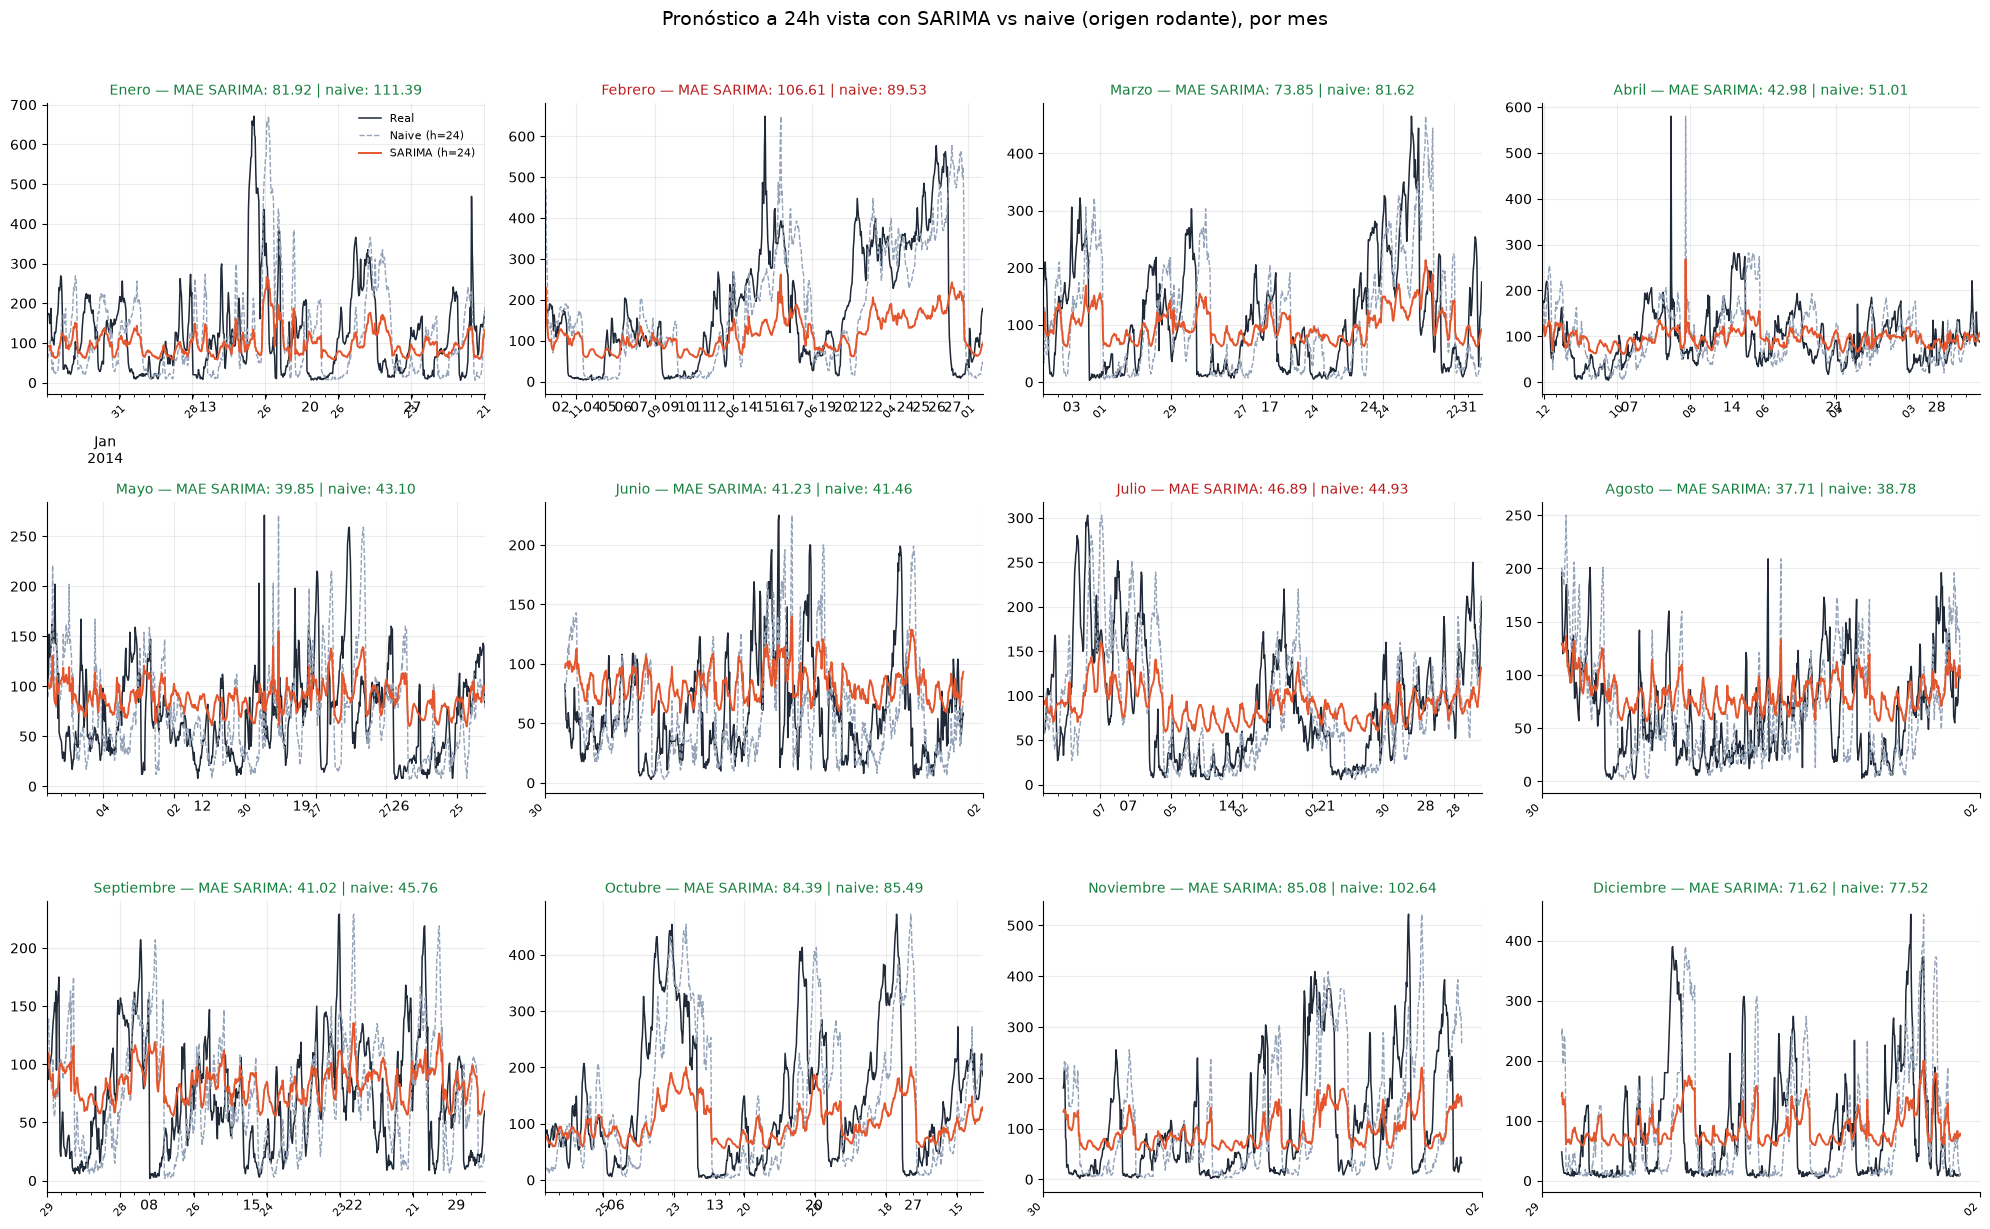

In [43]:
graficar_por_mes(y_true, pred_sarima, y, H, "SARIMA")

In [53]:
met_sarima = calcular_metricas(y_true, pred_sarima, y, H, UMBRAL, "SARIMA")
met_sarima

n     RMSE      MAE     MAPE  skill_RMSE  skill_MAE  \
subconjunto modelo                                                           
global      SARIMA  8696   85.378   62.444  200.026       0.139      0.075   
            naive   8696   99.127   67.524  212.873       0.000      0.000   
> 150       SARIMA  1751  157.032  135.862   51.554      -0.191     -0.260   
            naive   1751  131.815  107.852   45.163       0.000      0.000   

                    recall  precision     F1  
subconjunto modelo                            
global      SARIMA     NaN        NaN    NaN  
            naive      NaN        NaN    NaN  
> 150       SARIMA   0.170      0.624  0.267  
            naive    0.453      0.454  0.454

Como podemos ver, el resultado no es muy bueno, especialmente en episodios de alta contaminación, ya que el modelo tiene bastante a la media y no consigue capturar esos picos

## 2. SARIMAX: SARIMA + todas las exógenas

Ahora le pasamos al modelo, además de la propia serie, todas las exógenas del dataset: las variables de calendario (`cal_*`), las meteorológicas retardadas 24h (`*_obs_24`) y las tendencias (`*_trend_24_30`).

Como las meteorológicas están retardadas 24 horas, en el origen `t` ya conocemos sus valores para `t+1, ..., t+24`, y las de calendario son deterministas. Por tanto, al pronosticar a H=24 podemos pasarle al modelo las exógenas del horizonte sin usar información futura.

In [38]:
# ---- Exógenas: todas las columnas del dataset salvo la objetivo ----
X = df.drop(columns="pm2.5")
print(f"{X.shape[1]} exógenas: {list(X.columns)}")
print(f"NaN en exógenas: {X.isna().sum().sum()}")   # SARIMAX no admite NaN en exog


def estandarizar(X, fin_ref):
    """Estandariza X con la media y desviación del periodo hasta fin_ref (solo train, sin fuga)."""
    media, desv = X.loc[:fin_ref].mean(), X.loc[:fin_ref].std()
    desv = desv.replace(0, 1)   # por si alguna variable es constante en el periodo (p. ej. sin nieve)
    return (X - media) / desv


# Las exógenas tienen escalas muy distintas (PRES ~1000, dummies 0/1): estandarizar ayuda al optimizador
X_std = estandarizar(X, "2013-12-31 23:00:00")
X_train = X_std.loc[y_train.index]
X_test = X_std.loc[y_test.index]

17 exógenas: ['cal_sen_hora', 'cal_cos_hora', 'cal_sen_dia', 'cal_cos_dia', 'cal_sen_mes', 'cal_cos_mes', 'DEWP_obs_24', 'TEMP_obs_24', 'PRES_obs_24', 'Iws_obs_24', 'Is_obs_24', 'Ir_obs_24', 'viento_NE_obs_24', 'viento_NW_obs_24', 'viento_SE_obs_24', 'TEMP_trend_24_30', 'PRES_trend_24_30']
NaN en exógenas: 0


In [ ]:
def rolling_forecast_exog(fit_inicial, y_serie, X_eval, H):
    """
    Rolling forecast con exógenas: para cada origen t incorpora y(t) y X(t),
    y predice t+H pasando las exógenas conocidas de t+1 ... t+H. Devuelve (predicciones, reales).
    """
    fit = fit_inicial
    preds, idx_objetivo = [], []
    for t in y_serie.index[:-H]:
        # loc[t:t] (y no loc[[t]]) conserva la frecuencia horaria del índice; sin ella statsmodels
        # no sabe construir las fechas del horizonte cuando hay exógenas
        fit = fit.extend(y_serie.loc[t:t], exog=X_eval.loc[t:t])
        X_futuro = X_eval.loc[t + pd.Timedelta(hours=1): t + pd.Timedelta(hours=H)]
        fc = fit.get_forecast(steps=H, exog=X_futuro)
        preds.append(fc.predicted_mean.iloc[-1])
        idx_objetivo.append(t + pd.Timedelta(hours=H))
    pred = pd.Series(preds, index=pd.DatetimeIndex(idx_objetivo))
    return pred, y_serie.loc[pred.index]


def ajustar_sarimax(y_fit, X_fit, cfg):
    """Ajusta un SARIMAX con la configuración cfg = {order, seasonal_order, trend}."""
    return SARIMAX(
        y_fit,
        exog=X_fit,
        **cfg,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=200)

### 2.1 SARIMAX con los mismos parámetros que SARIMA

Primer SARIMAX con exactamente la misma configuración que el SARIMA base. Como lo único que cambia son las exógenas, la diferencia en métricas mide directamente cuánto aportan.

In [ ]:
cfg_sarima = dict(order=(2, 0, 2), seasonal_order=(1, 0, 1, 24), trend="n")   # igual que el SARIMA base

modelo_sarimax = ajustar_sarimax(y_train, X_train, cfg_sarima)

# Coeficientes de las exógenas: signo y significatividad
modelo_sarimax.summary().tables[1]

In [ ]:
pred_sarimax, y_true_sarimax = rolling_forecast_exog(modelo_sarimax, y_test, X_test, H)

In [ ]:
graficar_por_mes(y_true_sarimax, pred_sarimax, y, H, "SARIMAX")

In [ ]:
met_sarimax = calcular_metricas(y_true_sarimax, pred_sarimax, y, H, UMBRAL, "SARIMAX")
met_sarimax

### 2.2 Búsqueda de hiperparámetros: backtesting con 3 pliegues

Buscamos la mejor configuración con un backtesting de **ventana creciente** sobre el periodo de train (2010-2013), sin tocar el test (2014). Dividimos 2013 en tres cuatrimestres; en cada pliegue el modelo se entrena con todo lo anterior y se valida con un rolling forecast a H=24 sobre el cuatrimestre siguiente:

| Pliegue | Entrenamiento | Validación |
|---|---|---|
| 1 | 2010 → dic-2012 | ene-abr 2013 |
| 2 | 2010 → abr-2013 | may-ago 2013 |
| 3 | 2010 → ago-2013 | sep-dic 2013 |

Entre los tres pliegues se cubre un año completo, incluidos los picos de invierno.

- En cada pliegue el modelo se reajusta y las exógenas se estandarizan **solo con los datos de entrenamiento de ese pliegue**, para no filtrar información de validación.
- Fijamos d=0 porque el ADF rechaza la raíz unitaria; con d=1 el modelo tiende a mantener el último nivel, que es justo lo que ya hace el naive.
- Además de modelos estacionales, probamos modelos **sin componente estacional**: las variables de calendario (`cal_sen_hora`, `cal_cos_hora`, ...) ya recogen el ciclo diario, y son mucho más baratos de ajustar.
- El grid incluye la configuración del apartado 2.1, para que la búsqueda pueda quedarse con ella si es la mejor.
- Criterio de selección: **RMSE medio a H=24 en los tres pliegues**.

In [ ]:
# (fin_train, inicio_valid, fin_valid) de cada pliegue
pliegues = [
    ("2012-12-31 23:00:00", "2013-01-01 00:00:00", "2013-04-30 23:00:00"),
    ("2013-04-30 23:00:00", "2013-05-01 00:00:00", "2013-08-31 23:00:00"),
    ("2013-08-31 23:00:00", "2013-09-01 00:00:00", "2013-12-31 23:00:00"),
]

grid_sarimax = [
    dict(order=(1, 0, 1), seasonal_order=(0, 0, 0, 0),  trend="c"),
    dict(order=(2, 0, 1), seasonal_order=(0, 0, 0, 0),  trend="c"),
    dict(order=(2, 0, 2), seasonal_order=(0, 0, 0, 0),  trend="c"),
    dict(order=(1, 0, 1), seasonal_order=(1, 0, 1, 24), trend="c"),
    dict(order=(2, 0, 2), seasonal_order=(1, 0, 1, 24), trend="c"),
    cfg_sarima,                                                      # la del apartado 2.1
]

In [ ]:
def backtest_config(cfg, pliegues, H):
    """Rolling forecast a H horas en cada pliegue (reajustando el modelo). Devuelve el RMSE y MAE de cada pliegue."""
    rmses, maes = [], []
    for fin_train, ini_valid, fin_valid in pliegues:
        X_pliegue = estandarizar(X, fin_train)
        y_tr, y_va = y.loc[:fin_train], y.loc[ini_valid:fin_valid]

        fit = ajustar_sarimax(y_tr, X_pliegue.loc[y_tr.index], cfg)
        pred, y_real = rolling_forecast_exog(fit, y_va, X_pliegue.loc[y_va.index], H)

        mask = y_real.notna() & pred.notna()
        rmses.append(rmse(y_real[mask], pred[mask]))
        maes.append(mae(y_real[mask], pred[mask]))
    return rmses, maes


resultados_cv = []
for cfg in grid_sarimax:
    rmses, maes = backtest_config(cfg, pliegues, H)
    resultados_cv.append({**cfg,
                          "rmse_pliegues": np.round(rmses, 2), "rmse_medio": np.mean(rmses), "rmse_std": np.std(rmses),
                          "mae_medio": np.mean(maes)})
    print(f"order={cfg['order']} seasonal_order={cfg['seasonal_order']} trend={cfg['trend']} -> "
          f"RMSE medio: {np.mean(rmses):.3f} (± {np.std(rmses):.3f}) | MAE medio: {np.mean(maes):.3f}")

df_cv = pd.DataFrame(resultados_cv).sort_values("rmse_medio").reset_index(drop=True)
df_cv

### 2.3 Reentrenamiento con la mejor configuración y evaluación en test

Reentrenamos la configuración ganadora sobre todo el periodo fuera de test (2010-2013) y la evaluamos sobre test (2014) con el mismo rolling forecast y las mismas métricas que los modelos anteriores.

In [ ]:
mejor_cfg = df_cv.iloc[0][["order", "seasonal_order", "trend"]].to_dict()
print(f"Configuración ganadora: {mejor_cfg}")

modelo_sarimax_cv = ajustar_sarimax(y_train, X_train, mejor_cfg)
pred_sarimax_cv, y_true_sarimax_cv = rolling_forecast_exog(modelo_sarimax_cv, y_test, X_test, H)

In [ ]:
graficar_por_mes(y_true_sarimax_cv, pred_sarimax_cv, y, H, "SARIMAX cv")

In [ ]:
met_sarimax_cv = calcular_metricas(y_true_sarimax_cv, pred_sarimax_cv, y, H, UMBRAL, "SARIMAX cv")
met_sarimax_cv

## 3. Comparativa de modelos

Todas las métricas en test (2014) a H=24, globales y en episodios de alta contaminación (pm2.5 > UMBRAL).

In [ ]:
comparativa = pd.concat([met_sarima, met_sarimax, met_sarimax_cv])
# El naive es el mismo en todos los casos: nos quedamos con una sola copia
comparativa = comparativa[~comparativa.index.duplicated(keep="first")]
comparativa = comparativa.reindex(["global", f"> {UMBRAL}"], level="subconjunto")
comparativa